# Wine Quality Classification - Step 1: EDA

**Objective:** Explore the wine quality dataset and understand features before building ML models.

**Dataset:** 6,497 wines (1,599 red + 4,898 white)

**Target:** Quality (3-9 scale) → Convert to binary: Good (≥6) vs Bad (<6)

## 🎯 Executive Summary: Business Context

**Problem:** How can we automatically assess wine quality based on chemical properties?

**Solution:** Use machine learning to predict quality from measurable chemical characteristics.

**Stakeholder Value:**
- 🍷 Predict wine quality **without tasting** (cost savings)
- 📊 Identify which **chemical properties matter most** for quality
- 🎯 Understand **why** a wine is good or bad
- 💰 Support pricing decisions based on predicted quality

**Dataset:** 6,497 wines with 11 chemical properties and quality ratings (1-10 scale)

## 1. Load and Inspect Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
data_path = Path('data') / 'winequality-combined.csv'
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (6497, 13)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality wine_type  
0      9.4 

In [27]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB
None

Missing values:
fixed acidity           0
volatile acidity   

## 2. Sample Wines: What We're Predicting

In [28]:
# Show examples of good vs bad wines with their chemical properties
print("EXAMPLE GOOD WINES (Quality ≥ 7):")
print("=" * 80)
good_sample = df[df['quality'] >= 7][['wine_type', 'quality', 'alcohol', 'volatile acidity', 'sulphates', 'density']].sample(3, random_state=42)
for idx, (_, row) in enumerate(good_sample.iterrows(), 1):
    print(f"\nWine {idx}: {row['wine_type'].upper()} wine")
    print(f"  Quality Score: {row['quality']}/10 ⭐")
    print(f"  Alcohol: {row['alcohol']:.1f}%")
    print(f"  Volatile Acidity: {row['volatile acidity']:.2f} (lower is better)")
    print(f"  Sulphates: {row['sulphates']:.2f} (preservative)")
    print(f"  Density: {row['density']:.4f}")

print("\n" + "=" * 80)
print("EXAMPLE BAD WINES (Quality ≤ 4):")
print("=" * 80)
bad_sample = df[df['quality'] <= 4][['wine_type', 'quality', 'alcohol', 'volatile acidity', 'sulphates', 'density']].sample(3, random_state=42)
for idx, (_, row) in enumerate(bad_sample.iterrows(), 1):
    print(f"\nWine {idx}: {row['wine_type'].upper()} wine")
    print(f"  Quality Score: {row['quality']}/10")
    print(f"  Alcohol: {row['alcohol']:.1f}%")
    print(f"  Volatile Acidity: {row['volatile acidity']:.2f} (lower is better)")
    print(f"  Sulphates: {row['sulphates']:.2f} (preservative)")
    print(f"  Density: {row['density']:.4f}")

EXAMPLE GOOD WINES (Quality ≥ 7):

Wine 1: WHITE wine
  Quality Score: 7/10 ⭐
  Alcohol: 10.0%
  Volatile Acidity: 0.21 (lower is better)
  Sulphates: 0.57 (preservative)
  Density: 0.9930

Wine 2: WHITE wine
  Quality Score: 7/10 ⭐
  Alcohol: 11.5%
  Volatile Acidity: 0.18 (lower is better)
  Sulphates: 0.60 (preservative)
  Density: 0.9911

Wine 3: WHITE wine
  Quality Score: 7/10 ⭐
  Alcohol: 12.3%
  Volatile Acidity: 0.34 (lower is better)
  Sulphates: 0.40 (preservative)
  Density: 0.9903

EXAMPLE BAD WINES (Quality ≤ 4):

Wine 1: RED wine
  Quality Score: 4/10
  Alcohol: 10.9%
  Volatile Acidity: 0.47 (lower is better)
  Sulphates: 0.58 (preservative)
  Density: 0.9952

Wine 2: RED wine
  Quality Score: 4/10
  Alcohol: 10.5%
  Volatile Acidity: 1.02 (lower is better)
  Sulphates: 0.48 (preservative)
  Density: 0.9938

Wine 3: WHITE wine
  Quality Score: 4/10
  Alcohol: 9.8%
  Volatile Acidity: 0.35 (lower is better)
  Sulphates: 0.50 (preservative)
  Density: 0.9944


## 2. Explore Target Variable (Quality)

## 3. What Makes a Wine "Good"? - Business Interpretation

In [29]:
# Compare chemical properties of good vs bad wines
print("KEY DIFFERENCES BETWEEN GOOD AND BAD WINES:")
print("=" * 80)

good_wines_df = df[df['quality'] >= 6]
bad_wines_df = df[df['quality'] < 6]

key_features = ['alcohol', 'sulphates', 'citric acid', 'volatile acidity']

for feature in key_features:
    if feature in df.columns:
        good_avg = good_wines_df[feature].mean()
        bad_avg = bad_wines_df[feature].mean()
        difference = ((good_avg - bad_avg) / bad_avg * 100) if bad_avg != 0 else 0
        
        print(f"\n{feature.upper()}:")
        print(f"  Good wines average: {good_avg:.2f}")
        print(f"  Bad wines average:  {bad_avg:.2f}")
        print(f"  Difference: {difference:+.1f}%")
        
        if 'alcohol' in feature:
            print(f"  💡 Insight: Good wines tend to have HIGHER alcohol content")
        elif 'sulphates' in feature:
            print(f"  💡 Insight: Good wines tend to have MORE sulphates (preservative)")
        elif 'citric' in feature:
            print(f"  💡 Insight: Good wines tend to have MORE citric acid (freshness)")
        elif 'volatile' in feature:
            print(f"  💡 Insight: Good wines tend to have LESS volatile acidity (less vinegar smell)")

KEY DIFFERENCES BETWEEN GOOD AND BAD WINES:

ALCOHOL:
  Good wines average: 10.85
  Bad wines average:  9.87
  Difference: +9.9%
  💡 Insight: Good wines tend to have HIGHER alcohol content

SULPHATES:
  Good wines average: 0.54
  Bad wines average:  0.52
  Difference: +2.1%
  💡 Insight: Good wines tend to have MORE sulphates (preservative)

CITRIC ACID:
  Good wines average: 0.33
  Bad wines average:  0.30
  Difference: +7.5%
  💡 Insight: Good wines tend to have MORE citric acid (freshness)

VOLATILE ACIDITY:
  Good wines average: 0.31
  Bad wines average:  0.40
  Difference: -23.0%
  💡 Insight: Good wines tend to have LESS volatile acidity (less vinegar smell)


## 4. Red vs White Wine: Quality Patterns

In [30]:
# Create binary quality label if not already created
if 'quality_label' not in df.columns:
    df['quality_label'] = (df['quality'] >= 6).astype(int)

# Compare red vs white wine quality
red_wines = df[df['wine_type'] == 'red']
white_wines = df[df['wine_type'] == 'white']

red_good_pct = (red_wines['quality_label'] == 1).mean() * 100
white_good_pct = (white_wines['quality_label'] == 1).mean() * 100

print("RED vs WHITE WINE QUALITY COMPARISON:")
print("=" * 80)
print(f"\nRed Wines ({len(red_wines)} total):")
print(f"  Average Quality: {red_wines['quality'].mean():.2f}/10")
print(f"  Good wines: {red_good_pct:.1f}%")
print(f"  Quality range: {red_wines['quality'].min()}-{red_wines['quality'].max()}")

print(f"\nWhite Wines ({len(white_wines)} total):")
print(f"  Average Quality: {white_wines['quality'].mean():.2f}/10")
print(f"  Good wines: {white_good_pct:.1f}%")
print(f"  Quality range: {white_wines['quality'].min()}-{white_wines['quality'].max()}")

print(f"\n💡 Insight: ", end="")
if red_good_pct > white_good_pct:
    print(f"Red wines have {red_good_pct - white_good_pct:.1f}% higher good rating percentage")
else:
    print(f"White wines have {white_good_pct - red_good_pct:.1f}% higher good rating percentage")

RED vs WHITE WINE QUALITY COMPARISON:

Red Wines (1599 total):
  Average Quality: 5.64/10
  Good wines: 53.5%
  Quality range: 3-8

White Wines (4898 total):
  Average Quality: 5.88/10
  Good wines: 66.5%
  Quality range: 3-9

💡 Insight: White wines have 13.0% higher good rating percentage


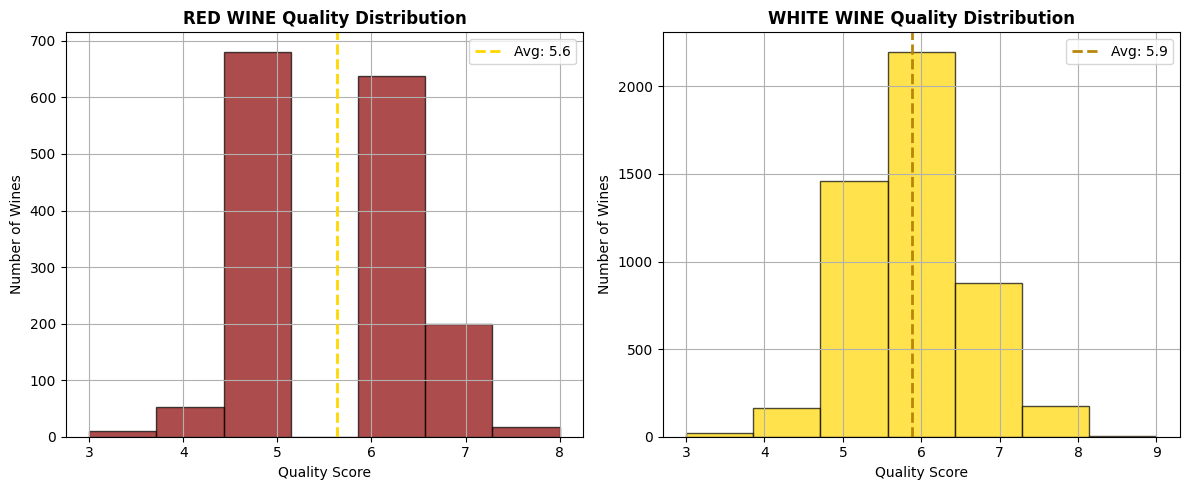

In [31]:
# Visualize red vs white quality distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

red_wines['quality'].hist(ax=axes[0], bins=7, color='#8B0000', alpha=0.7, edgecolor='black')
axes[0].set_title('RED WINE Quality Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Number of Wines')
axes[0].axvline(red_wines['quality'].mean(), color='gold', linestyle='--', linewidth=2, label=f'Avg: {red_wines["quality"].mean():.1f}')
axes[0].legend()

white_wines['quality'].hist(ax=axes[1], bins=7, color='#FFD700', alpha=0.7, edgecolor='black')
axes[1].set_title('WHITE WINE Quality Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Number of Wines')
axes[1].axvline(white_wines['quality'].mean(), color='darkgoldenrod', linestyle='--', linewidth=2, label=f'Avg: {white_wines["quality"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
# Quality distribution
print("Quality distribution:")
print(df['quality'].value_counts().sort_index())

# Create binary target: Good (≥6) vs Bad (<6)
df['quality_label'] = (df['quality'] >= 6).astype(int)
print("\nBinary classification (Good=1, Bad=0):")
print(df['quality_label'].value_counts())
print(f"\nGood wines: {(df['quality_label'] == 1).sum()} ({(df['quality_label'] == 1).mean()*100:.1f}%)")
print(f"Bad wines: {(df['quality_label'] == 0).sum()} ({(df['quality_label'] == 0).mean()*100:.1f}%)")

Quality distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Binary classification (Good=1, Bad=0):
quality_label
1    4113
0    2384
Name: count, dtype: int64

Good wines: 4113 (63.3%)
Bad wines: 2384 (36.7%)


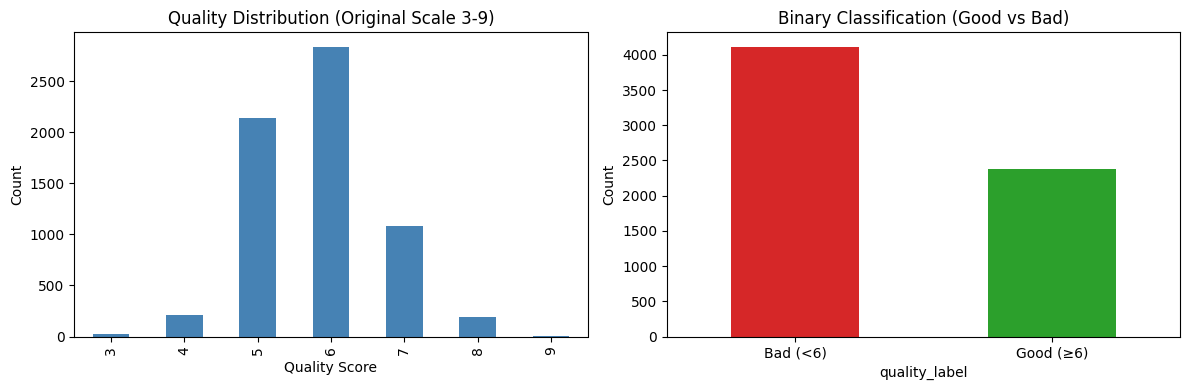

Quality is imbalanced: More good wines than bad wines


In [33]:
# Visualize quality distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original quality scale
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Quality Distribution (Original Scale 3-9)')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

# Binary classification
df['quality_label'].value_counts().plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Binary Classification (Good vs Bad)')
axes[1].set_xticklabels(['Bad (<6)', 'Good (≥6)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Quality is imbalanced: More good wines than bad wines")

## 3. Explore Features

In [34]:
# Get feature columns (exclude quality and wine_type)
feature_cols = [col for col in df.columns if col not in ['quality', 'quality_label', 'wine_type']]
print(f"Number of features: {len(feature_cols)}")
print(f"\nFeatures: {feature_cols}")

# Feature statistics
print("\nFeature Statistics:")
print(df[feature_cols].describe())

Number of features: 11

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Feature Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.

## 4. Feature Correlations with Quality

Correlation with Wine Quality (Good=1, Bad=0):
alcohol                 0.394676
citric acid             0.075739
free sulfur dioxide     0.044819
sulphates               0.035807
pH                      0.018842
residual sugar         -0.032484
total sulfur dioxide   -0.047585
fixed acidity          -0.067354
chlorides              -0.181908
volatile acidity       -0.267046
density                -0.268876
Name: quality_label, dtype: float64


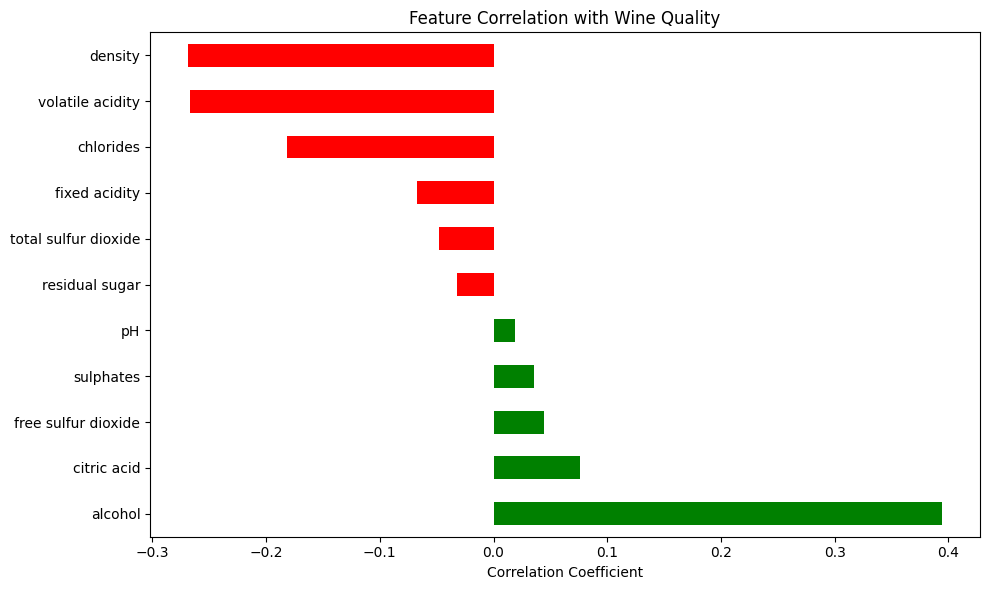

In [35]:
# Correlation with binary quality label
correlations = df[feature_cols + ['quality_label']].corr()['quality_label'].drop('quality_label').sort_values(ascending=False)
print("Correlation with Wine Quality (Good=1, Bad=0):")
print(correlations)

# Visualize correlations
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations])
plt.title('Feature Correlation with Wine Quality')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## 5. Feature Distributions by Quality

Top 4 features: ['alcohol', 'density', 'volatile acidity', 'chlorides']


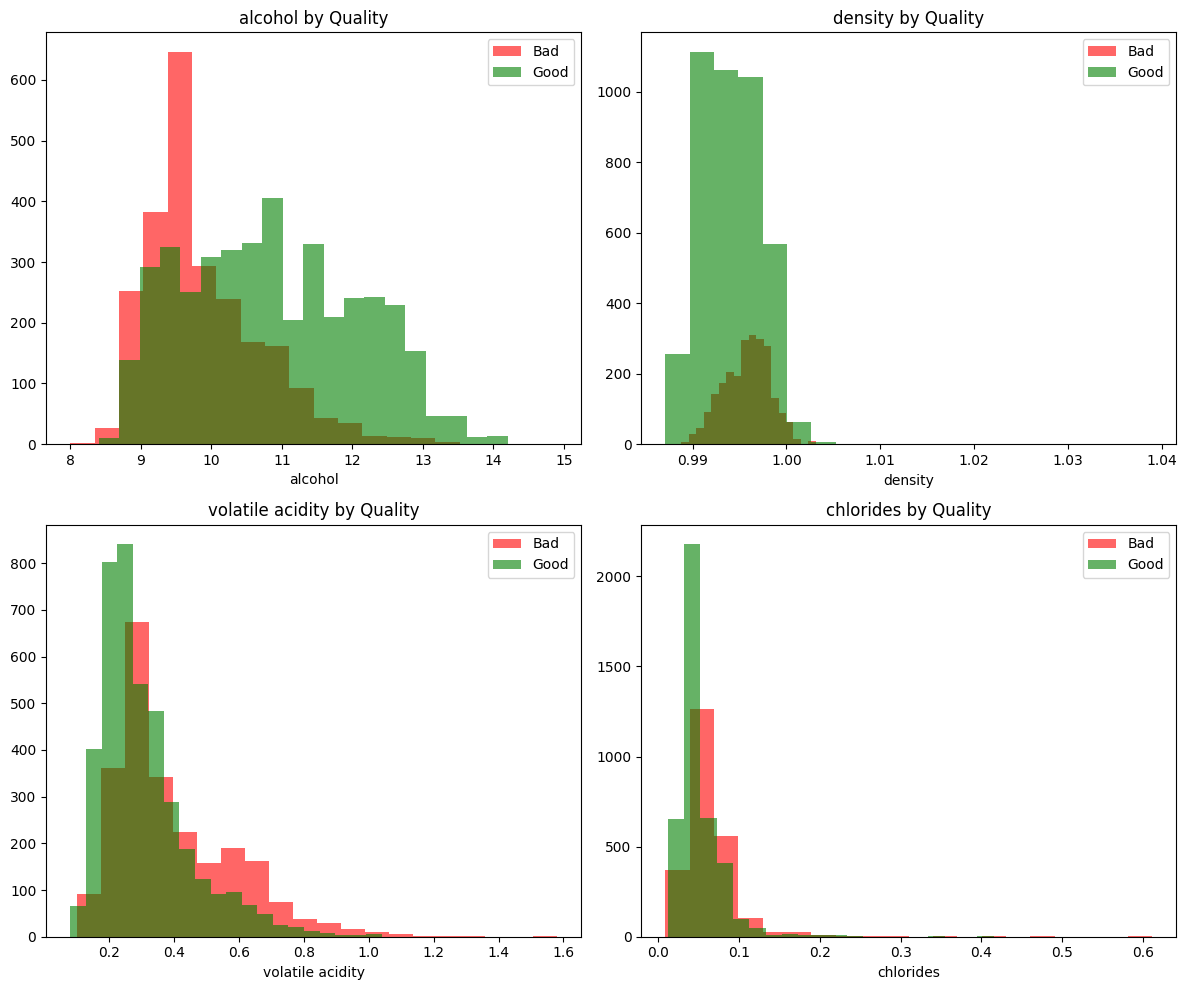

In [36]:
# Visualize top 4 most correlated features
top_features = correlations.abs().nlargest(4).index.tolist()
print(f"Top 4 features: {top_features}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    good_wines = df[df['quality_label'] == 1][feature]
    bad_wines = df[df['quality_label'] == 0][feature]
    
    axes[idx].hist(bad_wines, alpha=0.6, label='Bad', bins=20, color='red')
    axes[idx].hist(good_wines, alpha=0.6, label='Good', bins=20, color='green')
    axes[idx].set_title(f'{feature} by Quality')
    axes[idx].set_xlabel(feature)
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 6. Check for Outliers

In [37]:
# Summary statistics
print("Summary Statistics:")
print(df[feature_cols].describe())

# Check for extreme outliers
print("\nNo missing values: ✓")
print(f"Data types: All numeric ✓")
print(f"Class balance: Imbalanced (will handle during modeling)")

Summary Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000          

## 7. Key Findings

In [38]:
print("KEY FINDINGS FROM EDA:")
print("="*50)
print(f"1. Dataset size: {len(df)} wines")
print(f"2. Features: {len(feature_cols)} chemical properties")
print(f"3. Target: Binary classification (Good ≥6 vs Bad <6)")
print(f"4. Class balance: {(df['quality_label']==1).sum()} good, {(df['quality_label']==0).sum()} bad")
print(f"5. Top 3 predictive features: {', '.join(top_features[:3])}")
print(f"6. No missing values: ✓")
print(f"7. Ready for model training: ✓")

KEY FINDINGS FROM EDA:
1. Dataset size: 6497 wines
2. Features: 11 chemical properties
3. Target: Binary classification (Good ≥6 vs Bad <6)
4. Class balance: 4113 good, 2384 bad
5. Top 3 predictive features: alcohol, density, volatile acidity
6. No missing values: ✓
7. Ready for model training: ✓
